In [ ]:
!ls


circuits.csv  drivers.csv     races.csv    sample_data
drive	      qualifying.csv  results.csv


In [ ]:
import pandas as pd

races = pd.read_csv('/races.csv')
results = pd.read_csv('/results.csv')
qualifying = pd.read_csv('/qualifying.csv')
drivers = pd.read_csv('/drivers.csv')
circuits = pd.read_csv('/circuits.csv')

In [ ]:
results.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 
 17  statusId    

In [ ]:
races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         1125 non-null   object
 7   url          1125 non-null   object
 8   fp1_date     1125 non-null   object
 9   fp1_time     1125 non-null   object
 10  fp2_date     1125 non-null   object
 11  fp2_time     1125 non-null   object
 12  fp3_date     1125 non-null   object
 13  fp3_time     1125 non-null   object
 14  quali_date   1125 non-null   object
 15  quali_time   1125 non-null   object
 16  sprint_date  1125 non-null   object
 17  sprint_time  1125 non-null   object
dtypes: int64(4), object(14)
memory usage: 158.3+ KB


In [ ]:
df = results.merge(races[['raceId', 'year']], on='raceId')
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008


In [ ]:
df['venceu_do_pole'] = (df['grid'] == 1) & (df['positionOrder'] == 1)
df['venceu_do_pole'].value_counts()

,count
venceu_do_pole,
False,26278
True,481


Agora devo calcular a ***porcentagem***

In [ ]:
total_corridas = df['raceId'].nunique()
total_corridas

1125

In [ ]:
percentual = (481/total_corridas) * 100
percentual

42.75555555555556

42,76%

In [ ]:
df['decade'] = (df['year'] // 10) * 10
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,venceu_do_pole,decade
0,1,18,1,1,22,1,1,1,1,10.0,...,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008,True,2000
1,2,18,2,2,3,5,2,2,2,8.0,...,+5.478,5696094,41,3,1:27.739,217.586,1,2008,False,2000
2,3,18,3,3,7,7,3,3,3,6.0,...,+8.163,5698779,41,5,1:28.090,216.719,1,2008,False,2000
3,4,18,4,4,5,11,4,4,4,5.0,...,+17.181,5707797,58,7,1:28.603,215.464,1,2008,False,2000
4,5,18,5,1,23,3,5,5,5,4.0,...,+18.014,5708630,43,1,1:27.418,218.385,1,2008,False,2000


In [ ]:
vitorias_pole = df[df['venceu_do_pole'] == True].groupby('decade')['raceId'].nunique()
total_corridas_por_decada = df.groupby('decade')['raceId'].nunique()

percentual_por_decada = (vitorias_pole / total_corridas_por_decada) * 100
percentual_por_decada


,raceId
decade,
1950,41.666667
1960,37.000000
1970,36.805556
1980,28.205128
1990,42.592593
2000,50.000000
2010,50.505051
2020,52.336449


In [ ]:
import matplotlib.pyplot as plt



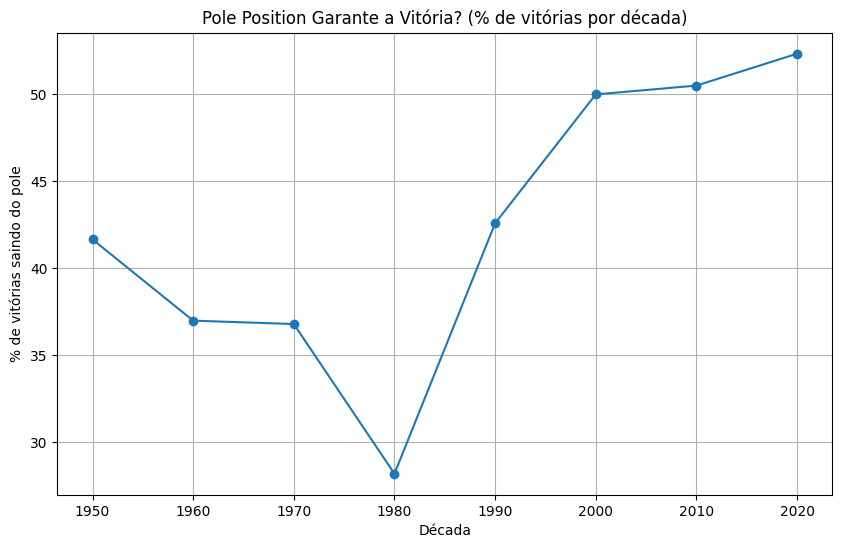

In [ ]:
percentual_por_decada.plot(kind='line', marker='o', figsize=(10,6))
plt.title('Pole Position Garante a Vitória? (% de vitórias por década)')
plt.xlabel('Década')
plt.ylabel('% de vitórias saindo do pole')
plt.grid(True)
plt.show()

In [ ]:
plt.savefig('grafico_pole_position.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

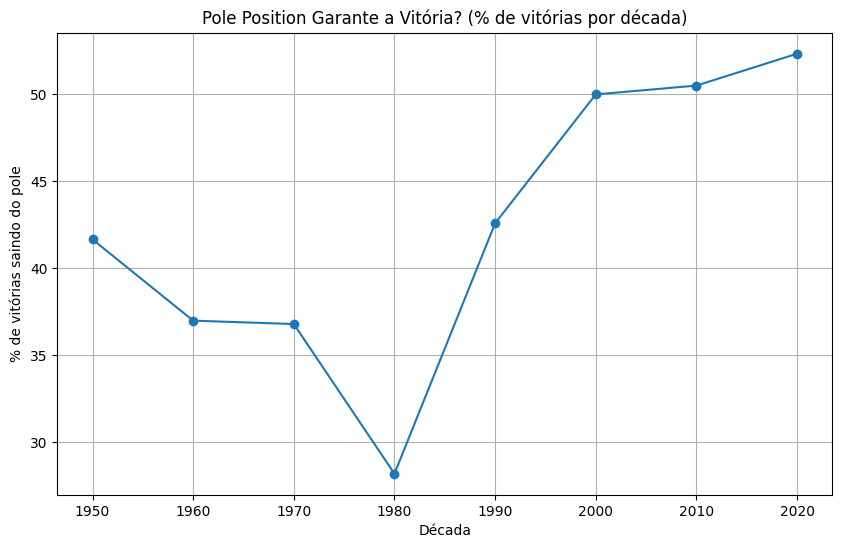

In [ ]:
percentual_por_decada.plot(kind='line', marker='o', figsize=(10,6))
plt.title('Pole Position Garante a Vitória? (% de vitórias por década)')
plt.xlabel('Década')
plt.ylabel('% de vitórias saindo do pole')
plt.grid(True)
plt.savefig('grafico_pole_position.png', dpi=300, bbox_inches='tight')
plt.show()

Pódio

In [ ]:
df['pole_no_podio'] = (df['grid'] == 1) & (df['positionOrder'] <= 3)

total_corridas = df['raceId'].nunique()
podios_do_pole = df[df['pole_no_podio'] == True]['raceId'].nunique()
percentual_podio = (podios_do_pole / total_corridas) * 100
percentual_podio

63.911111111111104

Circuito

In [ ]:
df_circuitos = df.merge(races[['raceId', 'circuitId']], on='raceId')
df_circuitos = df_circuitos.merge(circuits[['circuitId', 'name']], on='circuitId')

In [ ]:
vitorias_por_circuito = df_circuitos[df_circuitos['venceu_do_pole'] == True].groupby('name')['raceId'].nunique()
total_por_circuito = df_circuitos.groupby('name')['raceId'].nunique()

percentual_por_circuito = (vitorias_por_circuito / total_por_circuito) * 100

Extremos

In [ ]:
percentual_por_circuito.sort_values(ascending=False).head(5)

,raceId
name,
AVUS,100.0
Autodromo Internazionale del Mugello,100.0
Buddh International Circuit,100.0
Monsanto Park Circuit,100.0
Riverside International Raceway,100.0


In [ ]:
percentual_por_circuito.sort_values(ascending=True).head(5)

,raceId
name,
Autódromo Internacional Nelson Piquet,10.000000
Scandinavian Raceway,16.666667
Kyalami,20.000000
Circuit Bremgarten,20.000000
Korean International Circuit,25.000000


In [ ]:
Esses circuitos não existem mais

In [ ]:
circuitos_relevantes = total_por_circuito[total_por_circuito>=10].index
percentual_filtrado = percentual_por_circuito[circuitos_relevantes]

percentual_filtrado.sort_values(ascending=False).head(5)

,raceId
name,
Circuit de Barcelona-Catalunya,70.588235
Yas Marina Circuit,68.750000
Marina Bay Street Circuit,66.666667
Circuit Paul Ricard,61.111111
Shanghai International Circuit,58.823529


Circuitos de rua?!


In [ ]:
percentual_filtrado.sort_values(ascending=True).head(5)

,raceId
name,
Autódromo Internacional Nelson Piquet,10.000000
Kyalami,20.000000
Indianapolis Motor Speedway,26.315789
Circuit de Nevers Magny-Cours,27.777778
Brands Hatch,28.571429


Circuitos largos


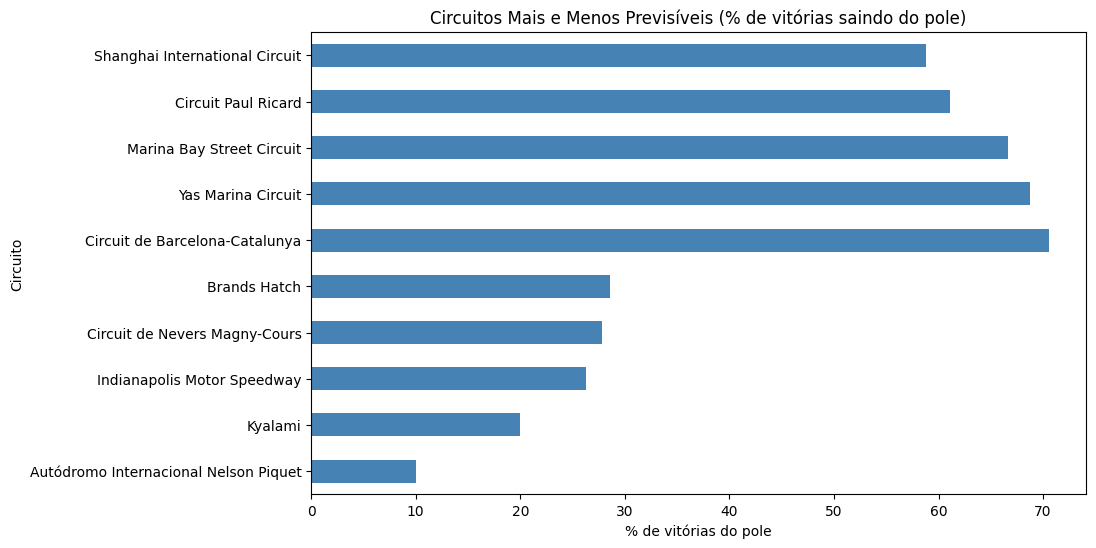

In [ ]:
top5_mais = percentual_filtrado.sort_values(ascending=False).head(5)
top5_menos = percentual_filtrado.sort_values(ascending=True).head(5)

comparacao = pd.concat([top5_menos, top5_mais])

comparacao.plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Circuitos Mais e Menos Previsíveis (% de vitórias saindo do pole)')
plt.xlabel('% de vitórias do pole')
plt.ylabel('Circuito')
plt.savefig('grafico_circuitos.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(percentual_por_decada)

decade
1950    41.666667
1960    37.000000
1970    36.805556
1980    28.205128
1990    42.592593
2000    50.000000
2010    50.505051
2020    52.336449
Name: raceId, dtype: float64


In [ ]:
print(comparacao)

name
Autódromo Internacional Nelson Piquet    10.000000
Kyalami                                  20.000000
Indianapolis Motor Speedway              26.315789
Circuit de Nevers Magny-Cours            27.777778
Brands Hatch                             28.571429
Circuit de Barcelona-Catalunya           70.588235
Yas Marina Circuit                       68.750000
Marina Bay Street Circuit                66.666667
Circuit Paul Ricard                      61.111111
Shanghai International Circuit           58.823529
Name: raceId, dtype: float64
